Neural Network Classifier Based on features selected by feauture importance insights from the XGB model on same data

Trains a `ThreeLayerNN` (PyTorch) on the feature set selected upstream by the XGBoost
pipeline (`Input_lists/XGB_CLASSIFY_INPUT.txt`). Architecture and tuned hyper-parameters
mirror Model 1 to enable a like-for-like comparison across feature sets.

workflow: drop highly-correlated features, train / val / test split,
standardize, train (early-stop on val), evaluate once on unseen test split, compute ROC / CM / loss / SHAP.


In [12]:
import sys
sys.path.append('../..')  # Add the parent directory to the system path to allow importing from Modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, confusion_matrix,
)

from Modules.models import ThreeLayerNN
from Modules.Utils import full_feature_data_preprocess

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    'mps' if torch.backends.mps.is_available()
    else 'cuda' if torch.cuda.is_available()
    else 'cpu'
)
print(f"Using device: {device}")


Using device: mps


## Data — load split, scale

In [13]:
DATA_PATH = '../../Data/AppML_InitialProject_train.h5'
FEATURE_LIST_PATH = '../input_lists/XGB_feature_importance_input_features.txt'
TARGET = 'p_Truth_isElectron'

X_trainval, X_test, y_trainval, y_test = full_feature_data_preprocess(
    DATA_PATH, TARGET, test_size=0.2,
)
# Makes the feature list for later use.
features = list(X_trainval.columns)

# Carve a validation set out of the training portion. The val set drives early
# stopping and the LR scheduler; the test set is touched once at the end.
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.2, random_state=SEED, stratify=y_trainval,
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"Features: {len(features)}")
print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")


Dataset loaded from ../../Data/AppML_InitialProject_train.h5 with shape (180000, 140)
Target variable 'p_Truth_isElectron' class distribution:
p_Truth_isElectron
0    0.79
1    0.21
Name: proportion, dtype: float64
No missing values detected in the dataset.
Dropped 44 highly correlated features
Features: 96
Train: (115200, 96)  Val: (28800, 96)  Test: (36000, 96)


In [14]:
# Hyperparameters larger layers due to more input features, will be tuned with Optuna later.


params = {
    'lr': 0.0007511249842440639,
    'first_layer': 256,
    'second_layer': 128,
    'third_layer': 64,
    'batch_size': 256,
}

model = ThreeLayerNN(
    input_size=X_train.shape[1],
    first_layer_size=params['first_layer'],
    second_layer_size=params['second_layer'],
    third_layer_size=params['third_layer'],
).to(device)

criterion = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=params['lr'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5)

def make_loader(X, y, batch_size, shuffle):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y.values, dtype=torch.float32),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, params['batch_size'], shuffle=True)
val_loader = make_loader(X_val, y_val, params['batch_size'], shuffle=False)


In [15]:
#Training loop with early stopping and LR scheduler

CHECKPOINT = 'saved_models/NN_FullFeature_final_model.pth'
EPOCHS = 1000
PATIENCE = 20

def run_epoch(loader, train):
    model.train(train)
    total_loss = 0.0
    grad_ctx = torch.enable_grad() if train else torch.no_grad()
    with grad_ctx:
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch).squeeze()
            loss = criterion(preds, y_batch)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
    return total_loss / len(loader)

train_losses, val_losses = [], []
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss = run_epoch(train_loader, train=True)
    va_loss = run_epoch(val_loader, train=False)
    scheduler.step(va_loss)

    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    print(f"Epoch {epoch:>4}/{EPOCHS}  Train: {tr_loss:.4f}  Val: {va_loss:.4f}")

    if va_loss < best_val_loss:
        best_val_loss = va_loss
        patience_counter = 0
        torch.save(model.state_dict(), CHECKPOINT)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (best val loss: {best_val_loss:.4f})")
            break

model.load_state_dict(torch.load(CHECKPOINT, weights_only=True))
# save used parameters to a text file
with open('saved_models/NN_final_params.txt', 'w') as f:
    for key, value in params.items():
        f.write(f"{key}: {value}\n")


Epoch    1/1000  Train: 0.1573  Val: 0.1205
Epoch    2/1000  Train: 0.1109  Val: 0.1127
Epoch    3/1000  Train: 0.1024  Val: 0.1071
Epoch    4/1000  Train: 0.0963  Val: 0.1047
Epoch    5/1000  Train: 0.0913  Val: 0.1018
Epoch    6/1000  Train: 0.0871  Val: 0.1005
Epoch    7/1000  Train: 0.0847  Val: 0.1025
Epoch    8/1000  Train: 0.0799  Val: 0.1041
Epoch    9/1000  Train: 0.0773  Val: 0.1053
Epoch   10/1000  Train: 0.0715  Val: 0.1041
Epoch   11/1000  Train: 0.0685  Val: 0.1047
Epoch   12/1000  Train: 0.0646  Val: 0.1090
Epoch   13/1000  Train: 0.0516  Val: 0.1067
Epoch   14/1000  Train: 0.0482  Val: 0.1092
Epoch   15/1000  Train: 0.0462  Val: 0.1109
Epoch   16/1000  Train: 0.0448  Val: 0.1137
Epoch   17/1000  Train: 0.0434  Val: 0.1159
Epoch   18/1000  Train: 0.0422  Val: 0.1173
Epoch   19/1000  Train: 0.0399  Val: 0.1180
Epoch   20/1000  Train: 0.0396  Val: 0.1186
Epoch   21/1000  Train: 0.0394  Val: 0.1192
Epoch   22/1000  Train: 0.0392  Val: 0.1194
Epoch   23/1000  Train: 0.0391  

## Test-set evaluation (single, final pass)

In [16]:
model.eval()
with torch.no_grad():
    y_proba = model(
        torch.tensor(X_test, dtype=torch.float32).to(device)
    ).squeeze().cpu().numpy()

y_pred = (y_proba > 0.5).astype(int)

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1:        {f1_score(y_test, y_pred):.4f}")


Accuracy:  0.9637
Precision: 0.9289
Recall:    0.8935
F1:        0.9109


## Diagnostics — ROC, confusion matrix, training curves

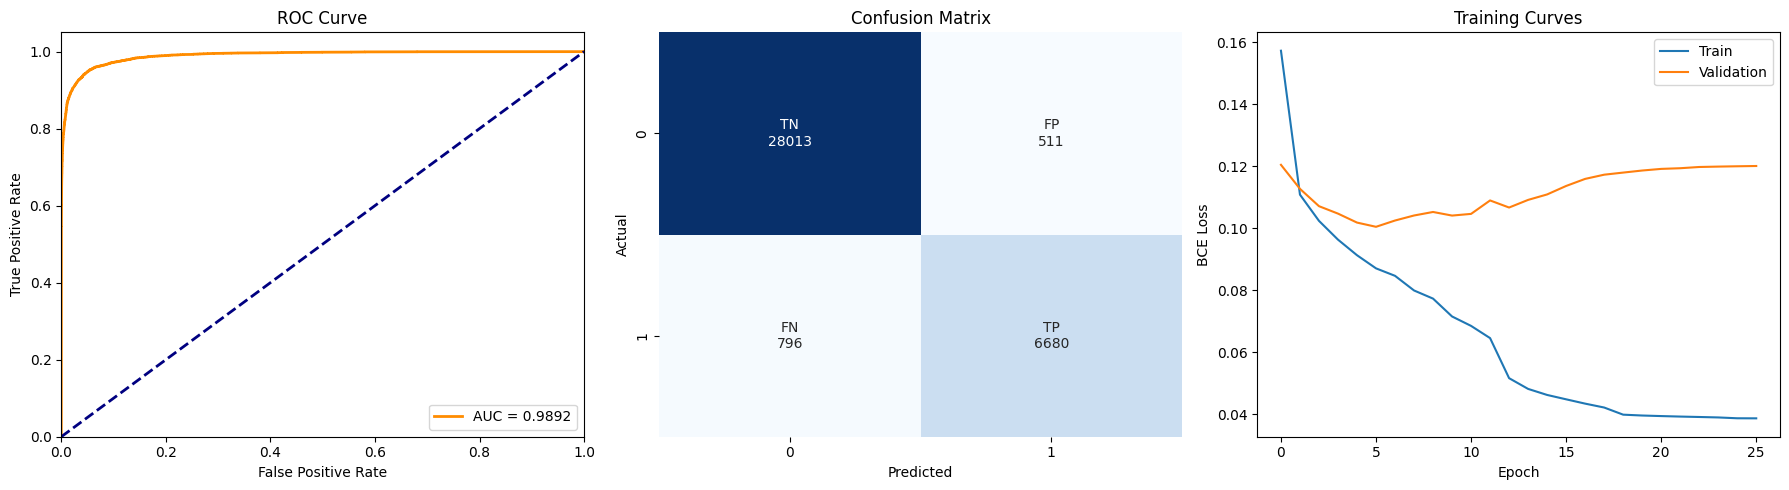

In [17]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')

cm_labels = np.array([['TN', 'FP'], ['FN', 'TP']])
cm_annot = np.array([[f"{l}\n{v}" for l, v in zip(rl, rv)]
                     for rl, rv in zip(cm_labels, cm)])
sns.heatmap(cm, annot=cm_annot, fmt='', cmap='Blues', cbar=False, ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix')

axes[2].plot(train_losses, label='Train')
axes[2].plot(val_losses, label='Validation')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('BCE Loss')
axes[2].set_title('Training Curves')
axes[2].legend()

plt.tight_layout()
plt.show()


/var/folders/b2/8bddj55101b95xgghvl2vmrh0000gn/T/ipykernel_71147/1487597020.py:23: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, features=X_test[explain_idx], feature_names=features)


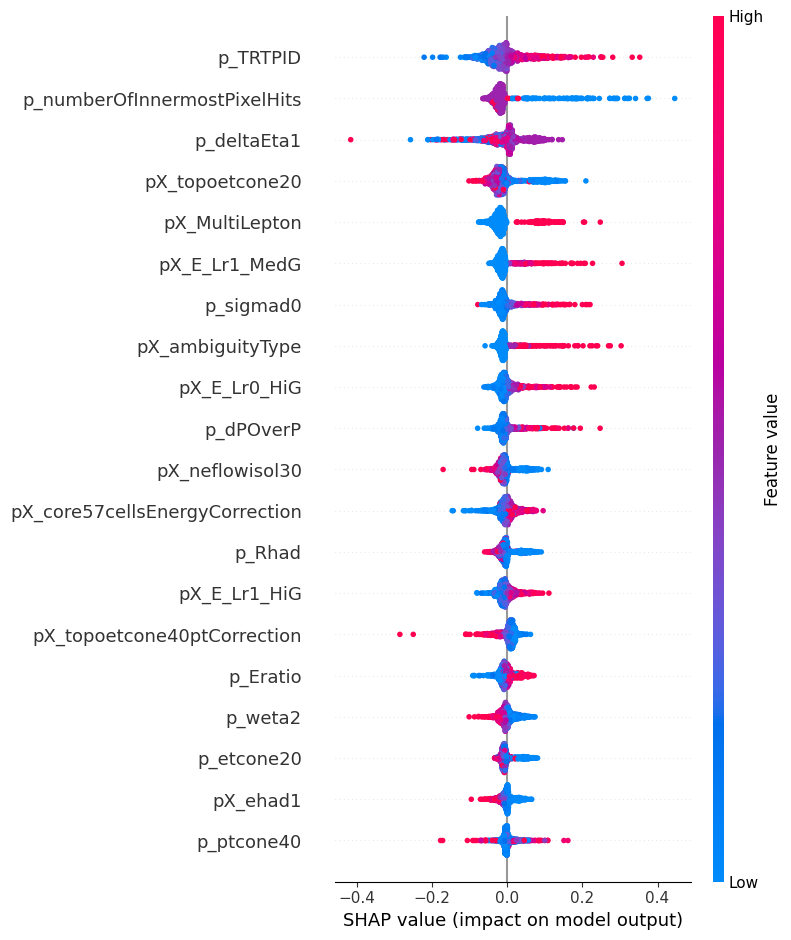

In [18]:
#shap values for feature importance



model_cpu = model.to('cpu').eval()

rng = np.random.default_rng(SEED)
bg_idx = rng.choice(len(X_train), size=min(200, len(X_train)), replace=False)
explain_idx = rng.choice(len(X_test), size=min(1000, len(X_test)), replace=False)

background = torch.tensor(X_train[bg_idx], dtype=torch.float32)
X_explain = torch.tensor(X_test[explain_idx], dtype=torch.float32)

explainer = shap.GradientExplainer(model_cpu, background)
shap_values = explainer.shap_values(X_explain)

# GradientExplainer returns either an array or a list (per output). Normalise
# to (n_samples, n_features).
if isinstance(shap_values, list):
    shap_values = shap_values[0]
shap_values = np.asarray(shap_values).squeeze()

shap.summary_plot(shap_values, features=X_test[explain_idx], feature_names=features)


In [19]:
#save 15 most important features to a text file

feature_importance = np.abs(shap_values).mean(axis=0)
feature_importance_list = [f for _, f in sorted(zip(feature_importance, features), reverse=True)][:15]

with open('../input_lists/NN_feature_importance_input_features.txt', 'w') as f:
    for feature in feature_importance_list:
        f.write(f"{feature}\n")

In [20]:
# NN trained on the 15 most important features from the shap values.

DATA_PATH = '../../Data/AppML_InitialProject_train.h5'
FEATURE_LIST_PATH = '../input_lists/NN_feature_importance_input_features.txt'
TARGET = 'p_Truth_isElectron'

X_trainval, X_test, y_trainval, y_test = full_feature_data_preprocess(
    DATA_PATH, TARGET, test_size=0.2,
)

with open(FEATURE_LIST_PATH) as f:
    features = [line.strip() for line in f if line.strip()]

X_trainval = X_trainval[features]
X_test = X_test[features]

# Carve a validation set out of the training portion. The val set drives early
# stopping and the LR scheduler; the test set is touched once at the end.
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.2, random_state=SEED, stratify=y_trainval,
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"Features: {len(features)}")
print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")

# Hyperparameters (these are the best ones found by the Optuna optimization, stored in tuned_params.txt)

params = {
    'lr': 0.0007511249842440639,
    'first_layer': 256,
    'second_layer': 32,
    'third_layer': 32,
    'batch_size': 256,
}

model = ThreeLayerNN(
    input_size=X_train.shape[1],
    first_layer_size=params['first_layer'],
    second_layer_size=params['second_layer'],
    third_layer_size=params['third_layer'],
).to(device)

criterion = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=params['lr'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5)

def make_loader(X, y, batch_size, shuffle):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y.values, dtype=torch.float32),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, params['batch_size'], shuffle=True)
val_loader = make_loader(X_val, y_val, params['batch_size'], shuffle=False)

#Training loop with early stopping and LR scheduler

CHECKPOINT = 'saved_models/NN_final_model_NN.pth'
EPOCHS = 1000
PATIENCE = 20

def run_epoch(loader, train):
    model.train(train)
    total_loss = 0.0
    grad_ctx = torch.enable_grad() if train else torch.no_grad()
    with grad_ctx:
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch).squeeze()
            loss = criterion(preds, y_batch)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
    return total_loss / len(loader)

train_losses, val_losses = [], []
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss = run_epoch(train_loader, train=True)
    va_loss = run_epoch(val_loader, train=False)
    scheduler.step(va_loss)

    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    print(f"Epoch {epoch:>4}/{EPOCHS}  Train: {tr_loss:.4f}  Val: {va_loss:.4f}")

    if va_loss < best_val_loss:
        best_val_loss = va_loss
        patience_counter = 0
        torch.save(model.state_dict(), CHECKPOINT)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (best val loss: {best_val_loss:.4f})")
            break

model.load_state_dict(torch.load(CHECKPOINT, weights_only=True))
# save used parameters to a text file
with open('saved_models/NN_final_params.txt', 'w') as f:
    for key, value in params.items():
        f.write(f"{key}: {value}\n")

model.eval()
with torch.no_grad():
    y_proba = model(
        torch.tensor(X_test, dtype=torch.float32).to(device)
    ).squeeze().cpu().numpy()

y_pred = (y_proba > 0.5).astype(int)

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1:        {f1_score(y_test, y_pred):.4f}")


Dataset loaded from ../../Data/AppML_InitialProject_train.h5 with shape (180000, 140)
Target variable 'p_Truth_isElectron' class distribution:
p_Truth_isElectron
0    0.79
1    0.21
Name: proportion, dtype: float64
No missing values detected in the dataset.
Dropped 44 highly correlated features
Features: 15
Train: (115200, 15)  Val: (28800, 15)  Test: (36000, 15)
Epoch    1/1000  Train: 0.1734  Val: 0.1358
Epoch    2/1000  Train: 0.1236  Val: 0.1260
Epoch    3/1000  Train: 0.1177  Val: 0.1214
Epoch    4/1000  Train: 0.1130  Val: 0.1222
Epoch    5/1000  Train: 0.1096  Val: 0.1151
Epoch    6/1000  Train: 0.1063  Val: 0.1186
Epoch    7/1000  Train: 0.1035  Val: 0.1103
Epoch    8/1000  Train: 0.1013  Val: 0.1103
Epoch    9/1000  Train: 0.0997  Val: 0.1083
Epoch   10/1000  Train: 0.0980  Val: 0.1077
Epoch   11/1000  Train: 0.0970  Val: 0.1059
Epoch   12/1000  Train: 0.0957  Val: 0.1063
Epoch   13/1000  Train: 0.0950  Val: 0.1042
Epoch   14/1000  Train: 0.0938  Val: 0.1042
Epoch   15/1000  T

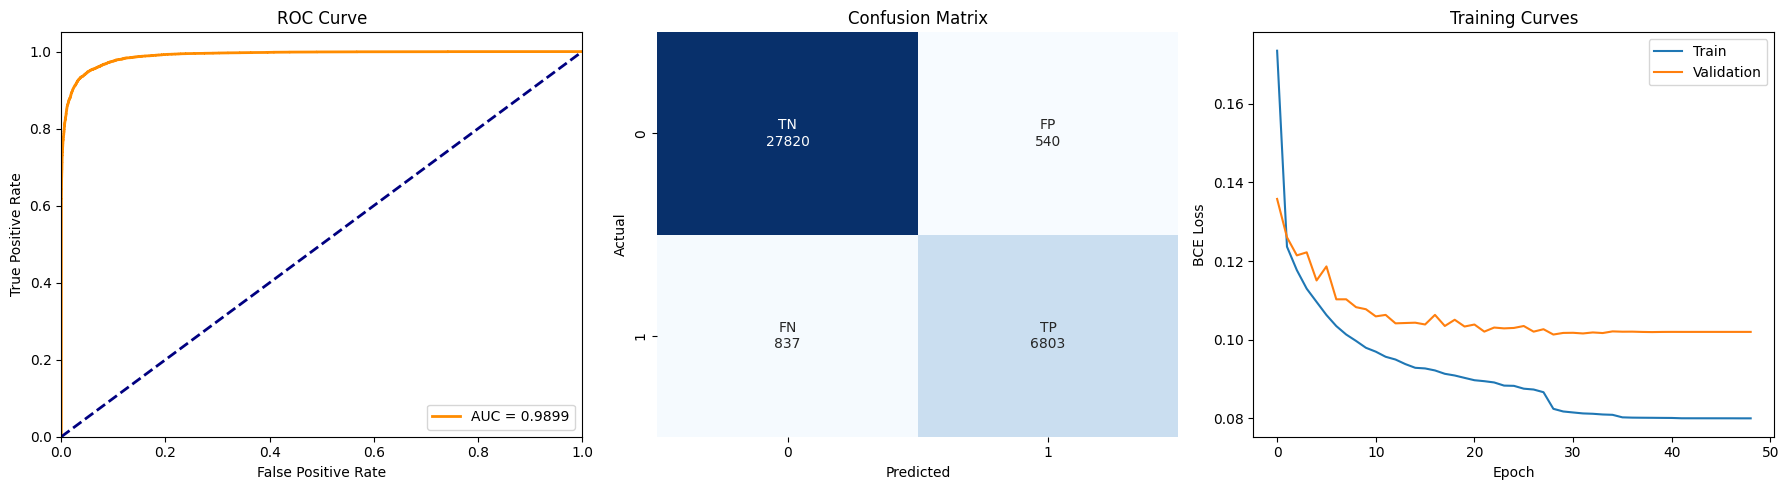

In [21]:
# ROC curve, AUC, and confusion matrix visualization

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')

cm_labels = np.array([['TN', 'FP'], ['FN', 'TP']])
cm_annot = np.array([[f"{l}\n{v}" for l, v in zip(rl, rv)]
                     for rl, rv in zip(cm_labels, cm)])
sns.heatmap(cm, annot=cm_annot, fmt='', cmap='Blues', cbar=False, ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix')

axes[2].plot(train_losses, label='Train')
axes[2].plot(val_losses, label='Validation')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('BCE Loss')
axes[2].set_title('Training Curves')
axes[2].legend()

plt.tight_layout()
plt.show()


/var/folders/b2/8bddj55101b95xgghvl2vmrh0000gn/T/ipykernel_71147/977294465.py:21: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, features=X_test[explain_idx], feature_names=features)


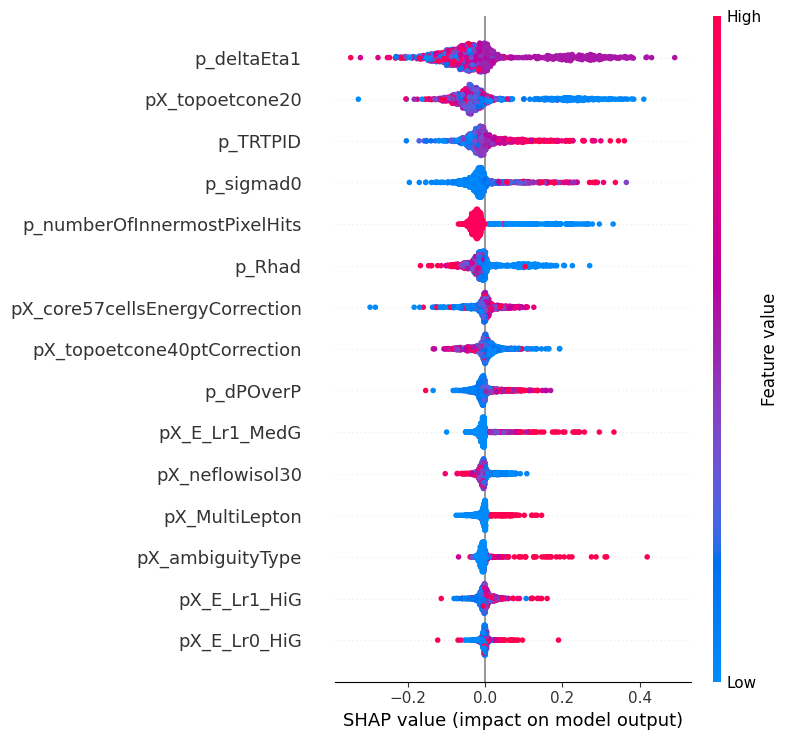

In [22]:
#shap values for feature importance

model_cpu = model.to('cpu').eval()

rng = np.random.default_rng(SEED)
bg_idx = rng.choice(len(X_train), size=min(200, len(X_train)), replace=False)
explain_idx = rng.choice(len(X_test), size=min(1000, len(X_test)), replace=False)

background = torch.tensor(X_train[bg_idx], dtype=torch.float32)
X_explain = torch.tensor(X_test[explain_idx], dtype=torch.float32)

explainer = shap.GradientExplainer(model_cpu, background)
shap_values = explainer.shap_values(X_explain)

# GradientExplainer returns either an array or a list (per output). Normalise
# to (n_samples, n_features).
if isinstance(shap_values, list):
    shap_values = shap_values[0]
shap_values = np.asarray(shap_values).squeeze()

shap.summary_plot(shap_values, features=X_test[explain_idx], feature_names=features)
